In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys
import re
from tqdm import tqdm

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities
path = "../results/refined_orbital_sweep/"
out_path = os.path.join(path, "combined_dt_sweep.h5")
collate=False

In [ ]:
# path relative to where you run this script
    path = "../results/refined_orbital_sweep/"
if collate=True:
    def _parse_folder(folder_name):
        """
        Extract a, e, i, raan from folder names like:
        sim_a1.40e+07_e0.8_i180.0_raan0.0
        """
        m = re.search(r"sim_a([^_]+)_e([^_]+)_i([^_]+)_raan([^_]+)", folder_name)
        if m:
            try:
                return (
                    float(m.group(1)),  # a
                    float(m.group(2)),  # e
                    float(m.group(3)),  # i
                    float(m.group(4)),  # raan
                )
            except ValueError:
                pass
        return -1.0, -1.0, -1.0, -1.0
    
    # Discover all simulation folders
    sweep_dirs = [
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d)) and d.startswith("sim_a")
    ]
    
    # Sort hierarchically by a, then e, then i, then raan
    sweep_dirs.sort(key=lambda d: _parse_folder(d))
    
    out_path = os.path.join(path, "combined_dt_sweep.h5")
    missing = []
    
    print(f"Collating {len(sweep_dirs)} folders into {out_path}...")
    
    with h5py.File(out_path, "w") as out_f:
        for folder in tqdm(sweep_dirs):
            a, e, i, raan = _parse_folder(folder)
    
            if a < 0:
                print(f"  [SKIP] {folder} — could not parse parameters")
                continue
    
            h5_path = os.path.join(path, folder, "mirror_states.h5")
            if not os.path.isfile(h5_path):
                print(f"  [SKIP] a={a}, e={e}, i={i}, raan={raan} — mirror_states.h5 not found")
                missing.append(folder)
                continue
    
            # Create a unique group name for this configuration
            group_name = f"a_{a:.6g}_e_{e:.6g}_i_{i:.6g}_raan_{raan:.6g}"
    
            with h5py.File(h5_path, "r") as src_f:
                dst_grp = out_f.create_group(group_name)
    
                # Copy everything from the source file ro ot into the new group
                for key in src_f.keys():
                    src_f.copy(key, dst_grp, name=key)
    
            #print(f"  [OK]   {folder}  →  {group_name}/")
    
    print(f"\nSaved combined file → {out_path}")
    
    if missing:
        print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")

In [2]:
def _h5_tree(item, indent=0, max_seg=2, first_only=False):
    """Recursively print an HDF5 tree, optionally only the first root group."""
    prefix = "  " * indent

    def _parse_root_group(name):
        if not name.startswith("a_"):
            return (-1.0, -1.0, -1.0, -1.0)
        parts = name.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
                float(parts[5]),
                float(parts[7]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0)

    def _segment_index(name):
        try:
            return int(name.split("_")[1])
        except (IndexError, ValueError):
            return -1

    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")

        children = sorted(item.keys(), key=_parse_root_group)

        if first_only and children:
            _h5_tree(item[children[0]], indent + 1, max_seg, first_only)
        else:
            for k in children:
                _h5_tree(item[k], indent + 1, max_seg, first_only)

    elif isinstance(item, h5py.Group):
        name = item.name.split("/")[-1]
        children = list(item.keys())

        seg_keys = sorted(
            [k for k in children if k.startswith("segment_")],
            key=_segment_index
        )
        other_keys = sorted(
            [k for k in children if not k.startswith("segment_")]
        )

        print(f"{prefix}┣ {name}/")

        for k in other_keys:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        if len(seg_keys) > max_seg:
            print(f"{'  ' * (indent + 1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")

    elif isinstance(item, h5py.Dataset):
        name = item.name.split("/")[-1]
        print(f"{prefix}┃  {name:30s}  {str(item.shape):20s}  {item.dtype}")


# ── Execute ──
with h5py.File(out_path, "r") as f:
    _h5_tree(f, max_seg=1, first_only=True)

/ (attrs: {})
  ┣ a_8e+06_e_0.8_i_0_raan_0/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  mirror_time                     (90000,)              float64
    ┃  phase                           (106817,)             object
    ┃  r_app_eci                       (106817, 3)           float64
    ┃  r_det_eci                       (106817, 3)           float64
    ┃  rel_pos_B                       (90000, 3)            float64
    ┃  rel_sigma_B                     (106817, 3)           float64
    ┃  sigma_app_star                  (106817, 3)           float64
    ┃  sigma_det_star                  (106817, 3)           float64
    ┃  time                            (106817,)             float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (90000, 6)            float64
      ┃  mirror_actuation                (90000, 6)            float64
      ┃  point_on_det_plane              (90000, 2)            float64
      ┃  position    

In [3]:
with h5py.File(out_path, "r") as src_f:

    def _parse_grp(x):
        if not x.startswith("a_"):
            return (-1.0, -1.0, -1.0, -1.0)
        parts = x.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
                float(parts[5]),
                float(parts[7]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0)

    def _get_ds(run_grp, name):
        """
        Fetch dataset 'name' from config/ if present, otherwise from the run root.
        """
        if "config" in run_grp and name in run_grp["config"]:
            return run_grp["config"][name][:]
        if name in run_grp:
            return run_grp[name][:]
        raise KeyError(f"Dataset '{name}' not found in '{run_grp.name}' or its config/ group")

    group_keys = sorted(
        [k for k in src_f.keys() if k.startswith("a_")],
        key=_parse_grp
    )

    num_runs = len(group_keys)
    print(f"Total number of simulation runs = {num_runs}")

    if num_runs == 0:
        raise ValueError("No simulation groups found in the HDF5 file.")

    first_group = group_keys[0]
    segs = sorted(
        int(k.split("_")[1])
        for k in src_f[first_group].keys()
        if k.startswith("segment_")
    )
    num_of_segs = len(segs)
    print(f"Number of segments = {num_of_segs}")

    phase = []
    full_times = []
    eng_times = []

    a_vals = []
    e_vals = []
    i_vals = []
    raan_vals = []

    r_app_eci = []
    r_det_eci = []
    rel_pos_B = []

    sigma_app_star = []
    sigma_det_star = []
    rel_sigma_B = []

    mirror_actuation = []
    desired_mirror_actuation = []
    point_on_det_plane = []

    for group in tqdm(group_keys):
        run_grp = src_f[group]
        a, e, i, raan = _parse_grp(group)

        a_vals.append(a)
        e_vals.append(e)
        i_vals.append(i)
        raan_vals.append(raan)

        # Strings
        phase_arr = _get_ds(run_grp, "phase")
        phase.append(np.array(phase_arr, dtype=str))

        # Times
        full_times.append(_get_ds(run_grp, "time"))
        eng_times.append(_get_ds(run_grp, "mirror_time"))

        # Positions
        r_app_eci.append(_get_ds(run_grp, "r_app_eci"))
        r_det_eci.append(_get_ds(run_grp, "r_det_eci"))
        rel_pos_B.append(_get_ds(run_grp, "rel_pos_B"))

        # Attitudes
        sigma_app_star.append(_get_ds(run_grp, "sigma_app_star"))
        sigma_det_star.append(_get_ds(run_grp, "sigma_det_star"))
        rel_sigma_B.append(_get_ds(run_grp, "rel_sigma_B"))

        # Segment data
        ma_segments = []
        dma_segments = []
        podp_segments = []

        for s in segs:
            seg_grp = run_grp[f"segment_{s}"]
            ma_segments.append(seg_grp["mirror_actuation"][:])
            dma_segments.append(seg_grp["desired_mirror_actuation"][:])
            podp_segments.append(seg_grp["point_on_det_plane"][:])

        mirror_actuation.append(ma_segments)
        desired_mirror_actuation.append(dma_segments)
        point_on_det_plane.append(podp_segments)

print("Data successfully loaded into lists!")

Total number of simulation runs = 192
Number of segments = 7


100%|██████████| 192/192 [04:02<00:00,  1.26s/it]

Data successfully loaded into lists!


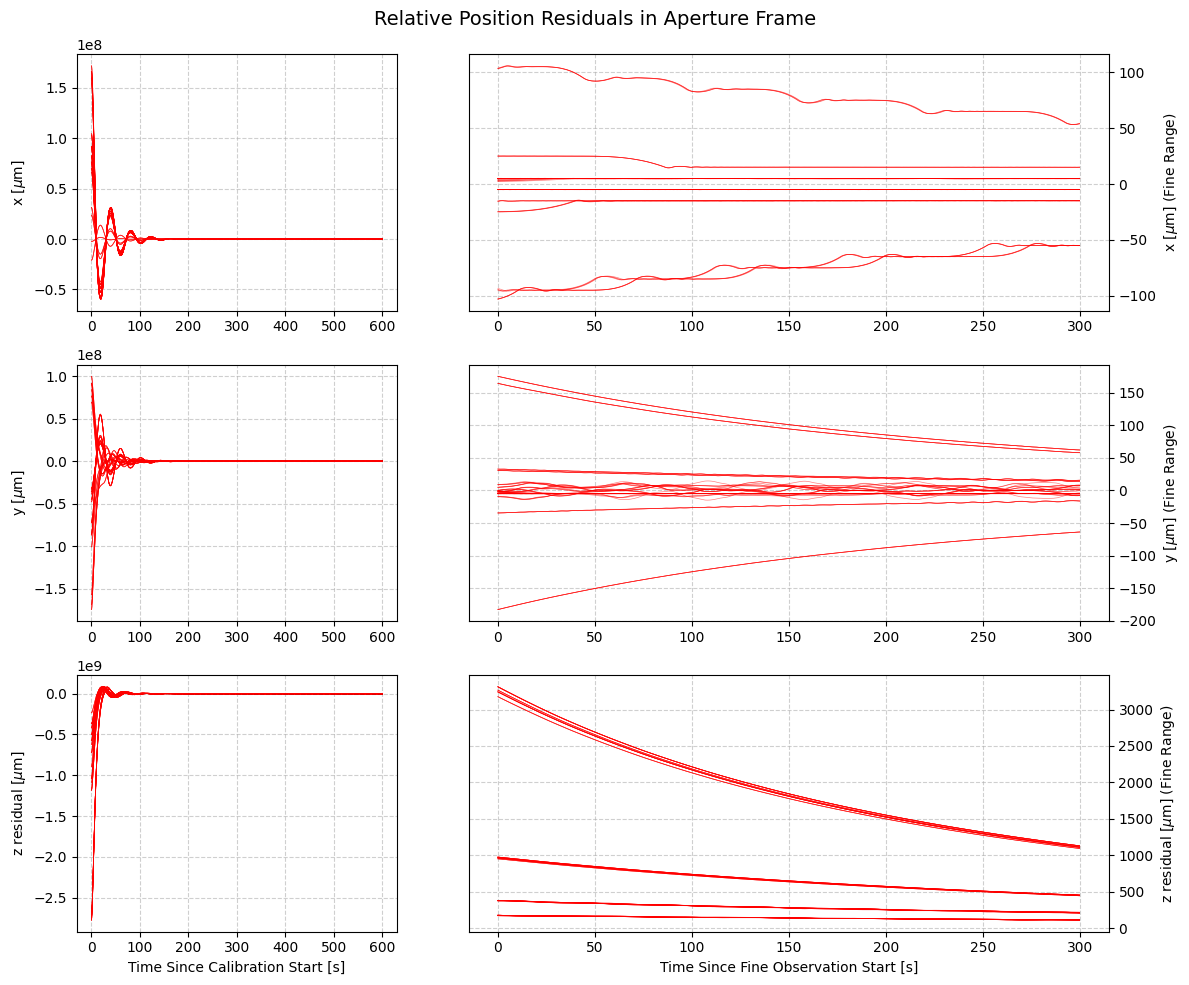

In [4]:
coord_letter = ["x", "y", "z"]

alpha_lines = 0.5
current_focal = 5000.0

rel_pos_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
rel_pos_fig.suptitle("Relative Position Residuals in Aperture Frame", fontsize=14)

rel_pos_ax = []

for row in range(3):
    ax_cal = rel_pos_fig.add_subplot(gs[row, 0])
    ax_fine = rel_pos_fig.add_subplot(gs[row, 1])

    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")

    rel_pos_ax.append((ax_cal, ax_fine))

rel_pos_ax[2][0].set_xlabel("Time Since Calibration Start [s]")
rel_pos_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

for coord in range(len(coord_letter)):
    label = coord_letter[coord]
    if coord == 2:
        label = "z residual"

    rel_pos_ax[coord][0].set_ylabel(f"{label} [$\\mu$m]")
    rel_pos_ax[coord][1].set_ylabel(f"{label} [$\\mu$m] (Fine Range)")
    rel_pos_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
    rel_pos_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

# Loop over all simulation runs and their parameters together
for i, (a, e, inc, raan) in enumerate(zip(a_vals, e_vals, i_vals, raan_vals)):
    t_eng = eng_times[i]
    rel = rel_pos_B[i]

    cal_idx = np.where(phase[i] == "Calibration")[0]
    fine_idx = np.where(phase[i] == "Fine Observation")[0]

    if len(cal_idx) > 0:
        cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
        cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
    else:
        cal_mask = np.zeros_like(t_eng, dtype=bool)

    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    cal_t = t_eng[cal_mask]
    cal_rel = rel[cal_mask]

    fine_t = t_eng[fine_mask]
    fine_rel = rel[fine_mask]

    if len(cal_t) > 0:
        cal_t = cal_t - cal_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    for coord in range(len(coord_letter)):
        cal_vals = cal_rel[:, coord] if len(cal_rel) > 0 else np.array([])
        fine_vals = fine_rel[:, coord] if len(fine_rel) > 0 else np.array([])

        if coord == 2:
            cal_vals = cal_vals - current_focal
            fine_vals = fine_vals - current_focal

        if len(cal_t) > 0 and len(cal_vals) > 0:
            rel_pos_ax[coord][0].plot(
                cal_t, cal_vals * 1e6,
                linewidth=0.5, color="red", alpha=alpha_lines
            )

        if len(fine_t) > 0 and len(fine_vals) > 0:
            rel_pos_ax[coord][1].plot(
                fine_t, fine_vals * 1e6,
                linewidth=0.5, color="red", alpha=alpha_lines
            )

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()

Plotting Point on Detector Plane: 100%|██████████| 192/192 [00:16<00:00, 11.95it/s]


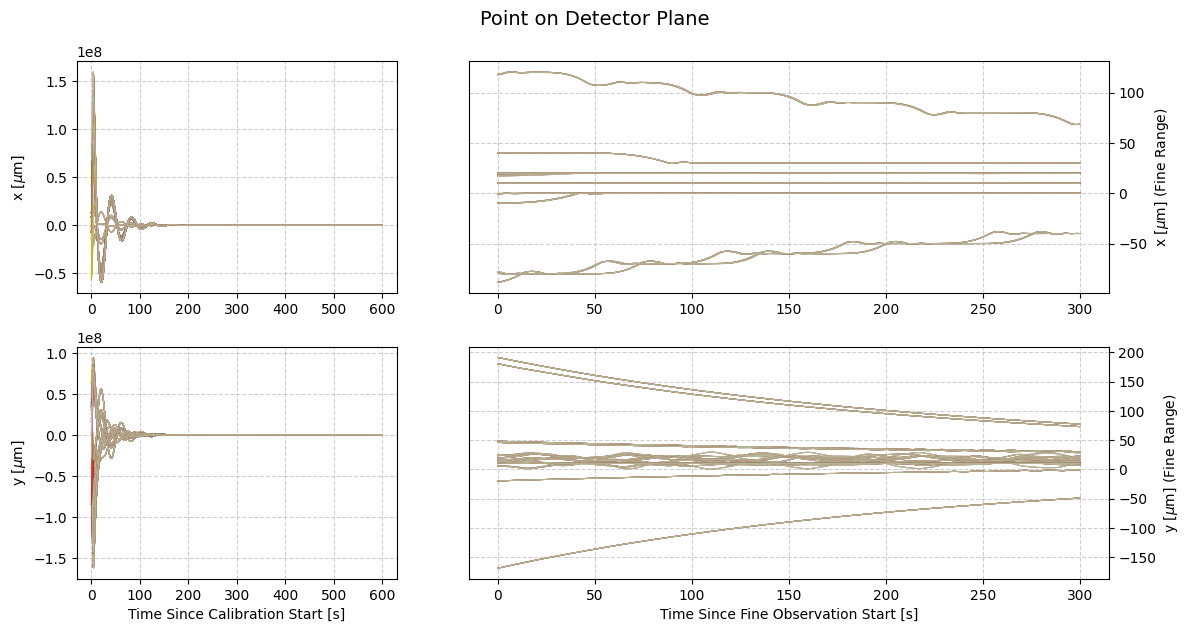

Plotting Mirror Actuation: 100%|██████████| 192/192 [00:39<00:00,  4.83it/s]


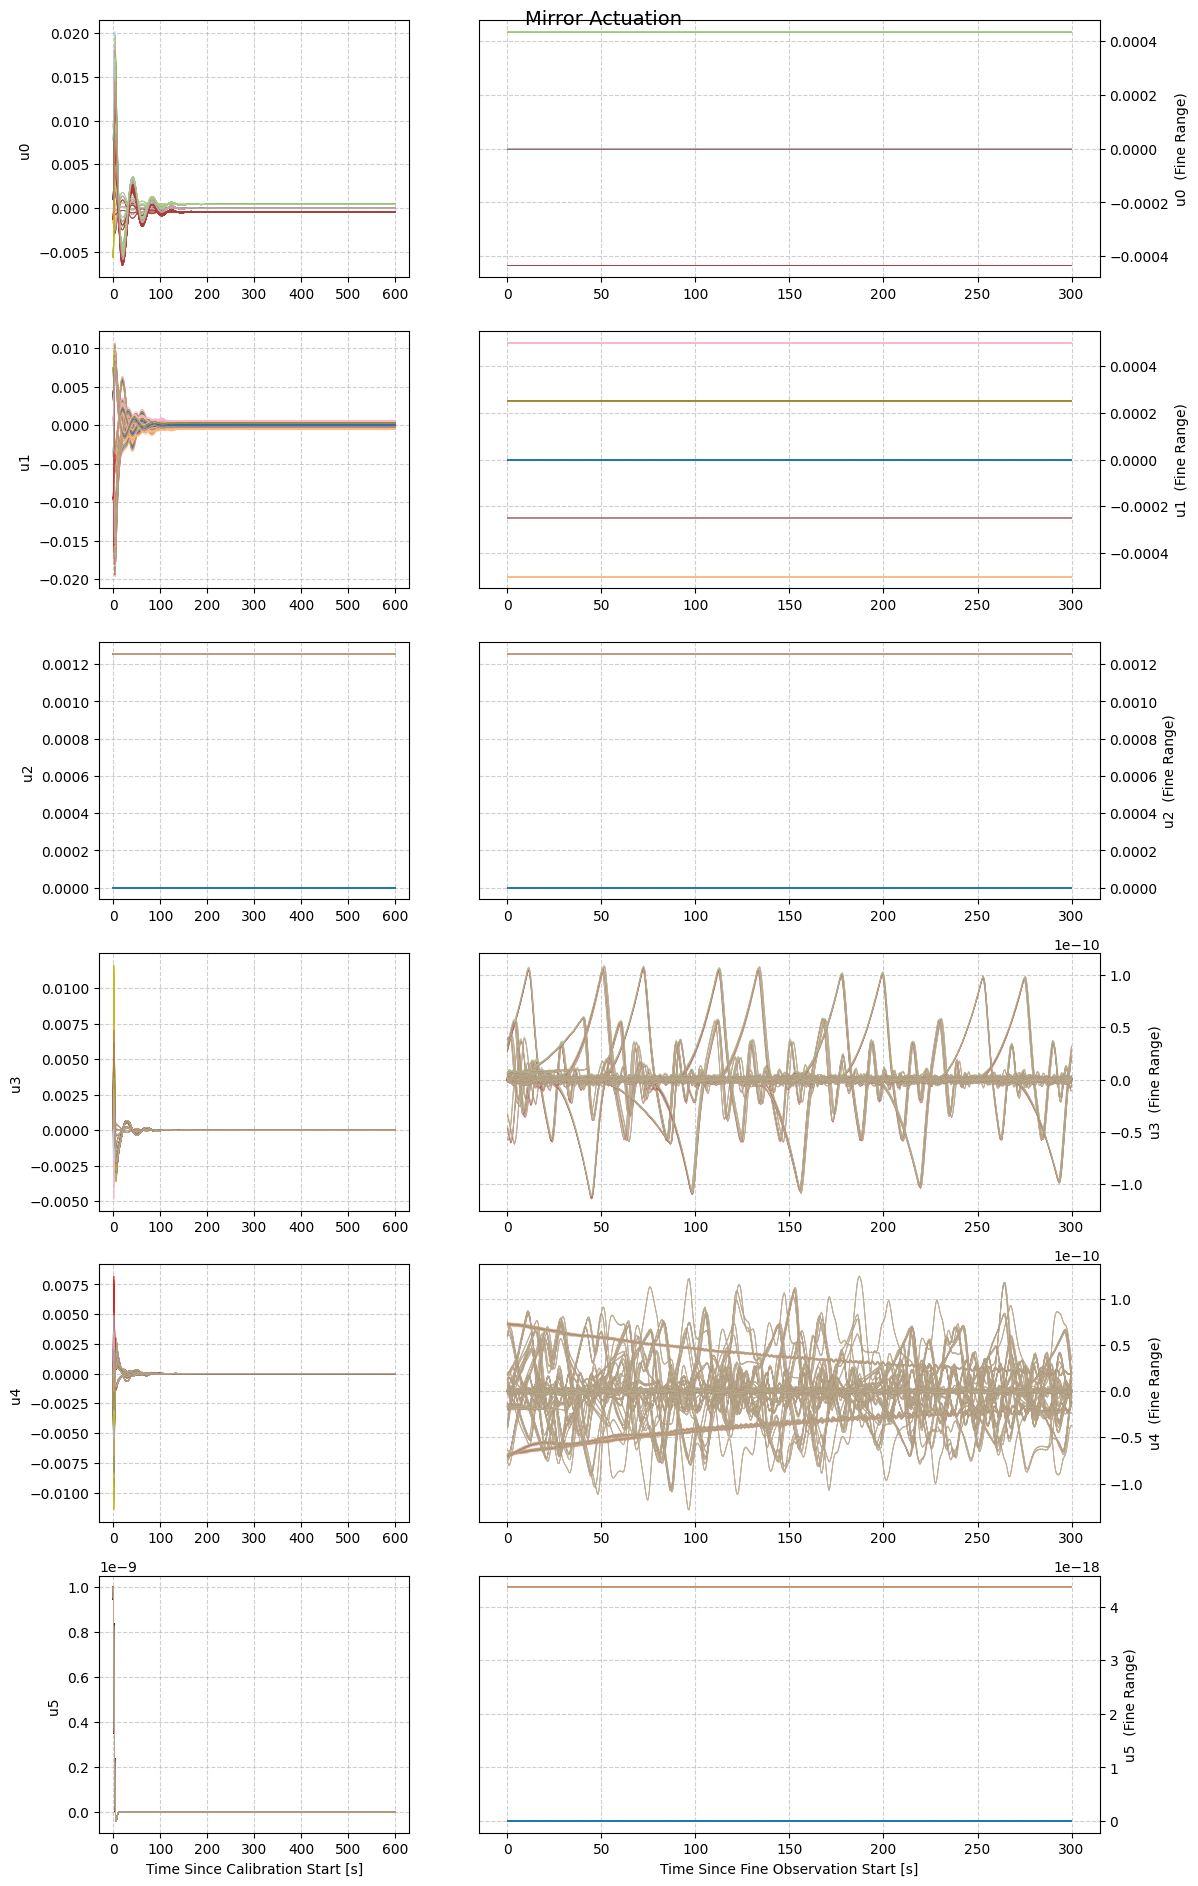

Plotting Desired Mirror Actuation: 100%|██████████| 192/192 [00:37<00:00,  5.17it/s]


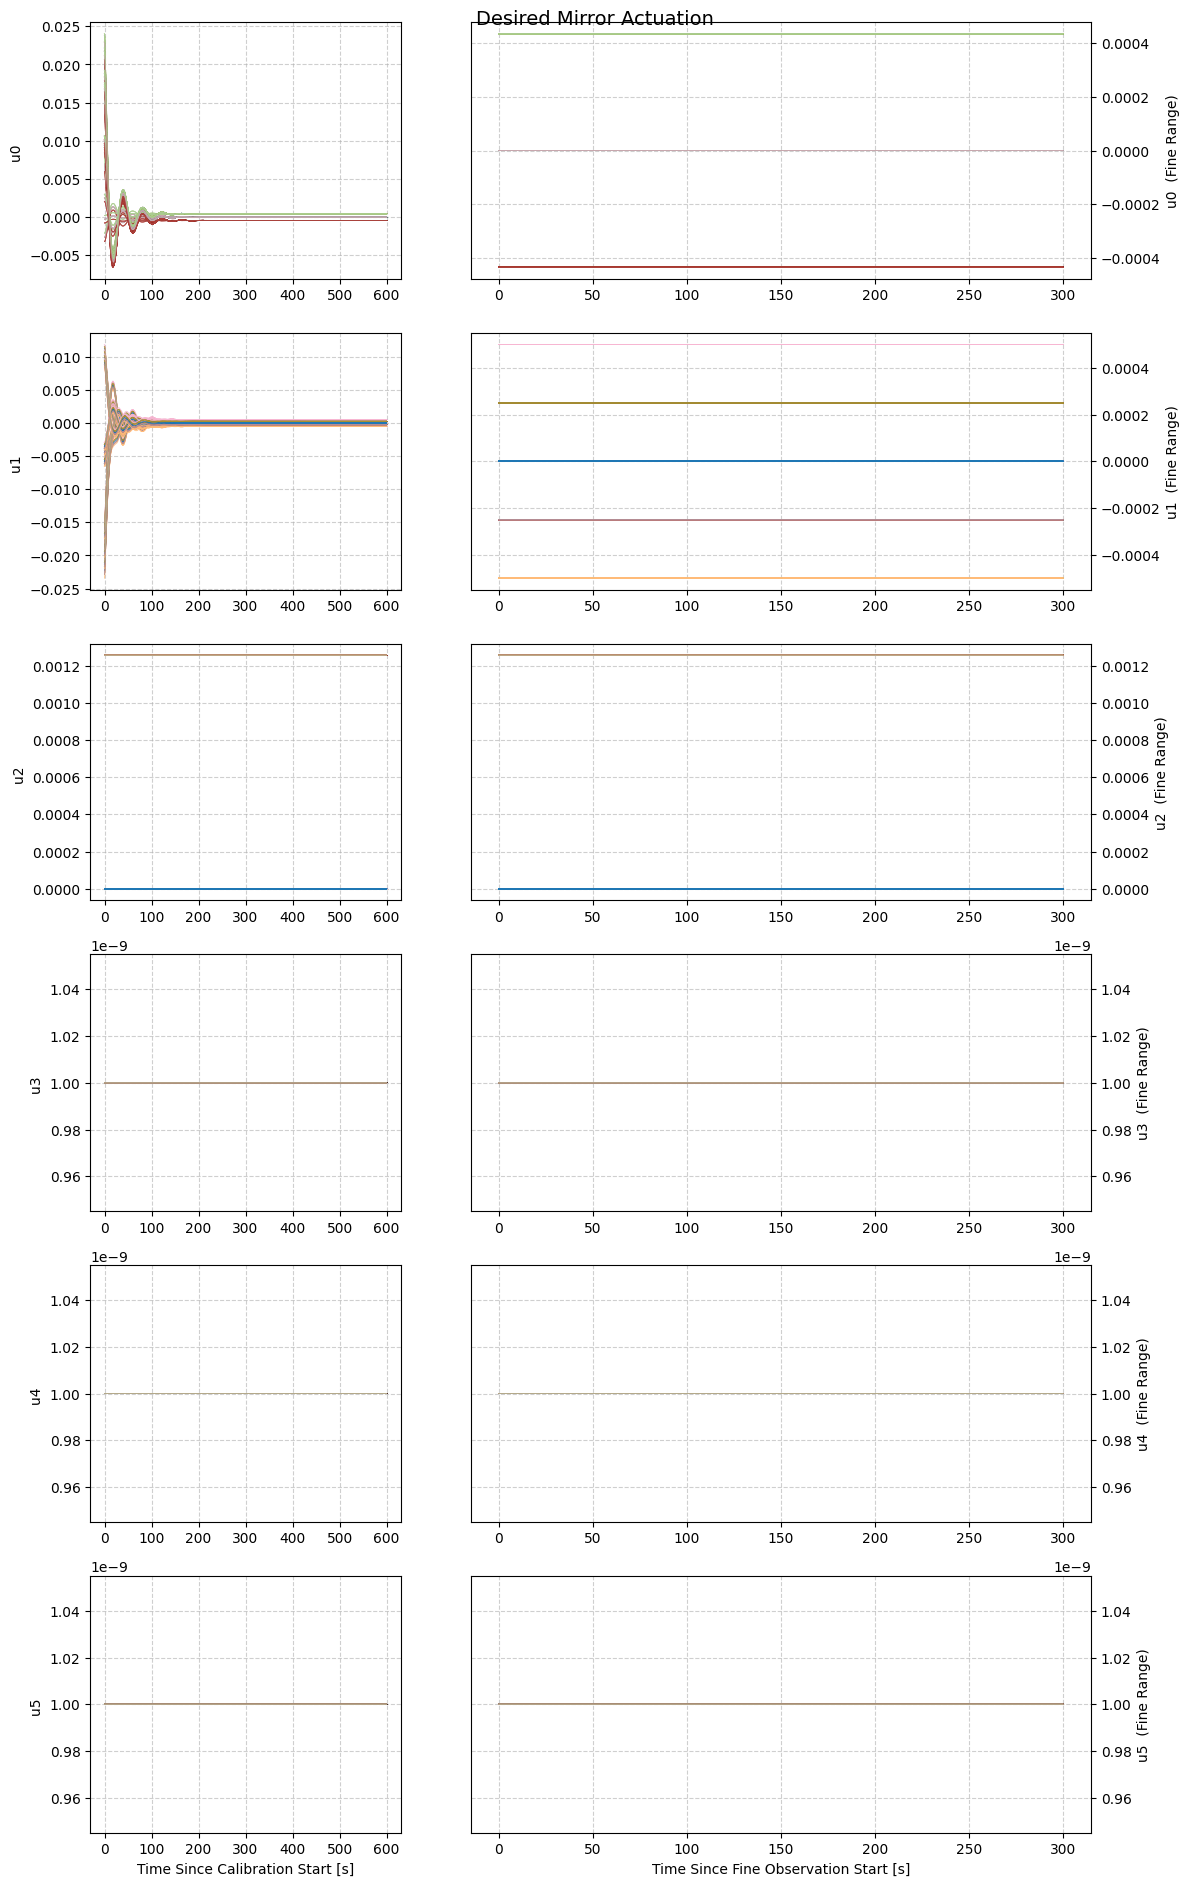

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

def plot_quantity_all_segments(
    quantity_list,
    title,
    component_labels=None,
    y_scale=1.0,
    y_suffix="",
    cmap_name="tab20",
    segment_alpha=0.35,
    line_width=0.6,
):
    """
    Plot every segment for every run, without averaging across segments.

    quantity_list:
        Outer list over runs.
        Inner list over segments.
        Each segment is an array of shape (T, N).
    """

    if len(quantity_list) == 0 or len(quantity_list[0]) == 0:
        raise ValueError(f"{title}: empty quantity_list")

    num_components = np.asarray(quantity_list[0][0]).shape[1]
    if component_labels is None:
        component_labels = [f"c{i}" for i in range(num_components)]

    max_segments = max(len(run) for run in quantity_list)
    cmap = plt.get_cmap(cmap_name, max(max_segments, 1))

    fig = plt.figure(figsize=(12, 3.2 * num_components))
    gs = gridspec.GridSpec(num_components, 2, width_ratios=[1, 2], figure=fig)
    fig.suptitle(title, fontsize=14)

    ax_pairs = []
    for row in range(num_components):
        ax_cal = fig.add_subplot(gs[row, 0])
        ax_fine = fig.add_subplot(gs[row, 1])

        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")

        ax_pairs.append((ax_cal, ax_fine))

    ax_pairs[-1][0].set_xlabel("Time Since Calibration Start [s]")
    ax_pairs[-1][1].set_xlabel("Time Since Fine Observation Start [s]")

    for coord in range(num_components):
        ax_pairs[coord][0].set_ylabel(f"{component_labels[coord]} {y_suffix}")
        ax_pairs[coord][1].set_ylabel(f"{component_labels[coord]} {y_suffix} (Fine Range)")
        ax_pairs[coord][0].grid(True, linestyle="--", alpha=0.6)
        ax_pairs[coord][1].grid(True, linestyle="--", alpha=0.6)

    for i in tqdm(range(num_runs), desc=f"Plotting {title}"):
        t_eng = eng_times[i]

        cal_idx = np.where(phase[i] == "Calibration")[0]
        fine_idx = np.where(phase[i] == "Fine Observation")[0]

        if len(cal_idx) > 0:
            cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
            cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
        else:
            cal_mask = np.zeros_like(t_eng, dtype=bool)

        if len(fine_idx) > 0:
            fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
            fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
        else:
            fine_mask = np.zeros_like(t_eng, dtype=bool)

        cal_t = t_eng[cal_mask]
        fine_t = t_eng[fine_mask]

        if len(cal_t) > 0:
            cal_t = cal_t - cal_t[0]
        if len(fine_t) > 0:
            fine_t = fine_t - fine_t[0]

        # Plot each segment separately
        for s, seg_data in enumerate(quantity_list[i]):
            seg_data = np.asarray(seg_data)

            if seg_data.ndim != 2 or seg_data.shape[1] != num_components:
                raise ValueError(
                    f"{title}: run {i}, segment {s} has shape {seg_data.shape}, "
                    f"expected (T, {num_components})"
                )

            seg_color = cmap(s % cmap.N)

            cal_vals_all = seg_data[cal_mask]
            fine_vals_all = seg_data[fine_mask]

            for coord in range(num_components):
                cal_vals = cal_vals_all[:, coord] if len(cal_vals_all) > 0 else np.array([])
                fine_vals = fine_vals_all[:, coord] if len(fine_vals_all) > 0 else np.array([])

                if len(cal_t) > 0 and len(cal_vals) > 0:
                    ax_pairs[coord][0].plot(
                        cal_t,
                        cal_vals * y_scale,
                        linewidth=line_width,
                        color=seg_color,
                        alpha=segment_alpha,
                    )

                if len(fine_t) > 0 and len(fine_vals) > 0:
                    ax_pairs[coord][1].plot(
                        fine_t,
                        fine_vals * y_scale,
                        linewidth=line_width,
                        color=seg_color,
                        alpha=segment_alpha,
                    )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)
    plt.show()


# Point on detector plane: x and y
plot_quantity_all_segments(
    point_on_det_plane,
    title="Point on Detector Plane",
    component_labels=["x", "y"],
    y_scale=1e6,
    y_suffix="[point on det]",
    cmap_name="tab20",
    segment_alpha=0.45,
    line_width=0.7,
)

# Mirror actuation: 6 components
plot_quantity_all_segments(
    mirror_actuation,
    title="Mirror Actuation",
    component_labels=[f"u{i}" for i in range(6)],
    y_scale=1.0,
    y_suffix="",
    cmap_name="tab20",
    segment_alpha=0.35,
    line_width=0.6,
)

# Desired mirror actuation: 6 components
plot_quantity_all_segments(
    desired_mirror_actuation,
    title="Desired Mirror Actuation",
    component_labels=[f"u{i}" for i in range(6)],
    y_scale=1.0,
    y_suffix="",
    cmap_name="tab20",
    segment_alpha=0.35,
    line_width=0.6,
)

Building detector heatmaps: 100%|██████████| 192/192 [00:08<00:00, 22.46it/s] 
/tmp/SLURM_7587966/ipykernel_600901/3766350114.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Heatmaps built.


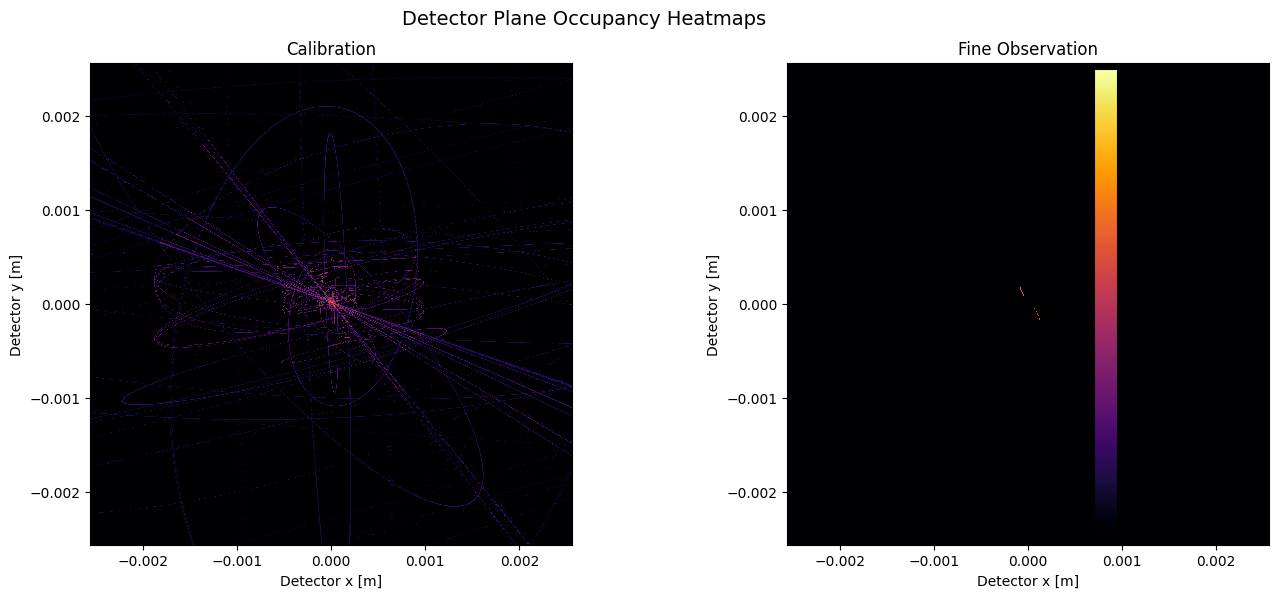

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

det_num_pixels = 2048
det_pixel_size = 2.5e-6  # meters
det_size_m = det_num_pixels * det_pixel_size
half_size_m = det_size_m / 2.0

def _accumulate_centered_heatmap(heatmap, xy_m):
    """
    Accumulate (x, y) points in meters into a centered detector heatmap.

    Detector spans:
        x in [-half_size_m, +half_size_m)
        y in [-half_size_m, +half_size_m)

    The origin (0,0) is centered in the image, not at the corner.
    """
    if xy_m.size == 0:
        return

    xy_m = np.asarray(xy_m)
    if xy_m.ndim != 2 or xy_m.shape[1] != 2:
        raise ValueError(f"Expected shape (N, 2), got {xy_m.shape}")

    x = xy_m[:, 0]
    y = xy_m[:, 1]

    # Convert meters -> pixel indices with the detector centered at (0,0)
    x_idx = np.floor((x + half_size_m) / det_pixel_size).astype(int)
    y_idx = np.floor((y + half_size_m) / det_pixel_size).astype(int)

    valid = (
        (x_idx >= 0) & (x_idx < det_num_pixels) &
        (y_idx >= 0) & (y_idx < det_num_pixels)
    )

    np.add.at(heatmap, (y_idx[valid], x_idx[valid]), 1)

# ---------------------------------------------------------------------
# Build calibration / fine-observation detector heatmaps
# ---------------------------------------------------------------------
cal_heat = np.zeros((det_num_pixels, det_num_pixels), dtype=np.float64)
fine_heat = np.zeros((det_num_pixels, det_num_pixels), dtype=np.float64)

for i in tqdm(range(num_runs), desc="Building detector heatmaps"):
    t_eng = eng_times[i]

    cal_idx = np.where(phase[i] == "Calibration")[0]
    fine_idx = np.where(phase[i] == "Fine Observation")[0]

    if len(cal_idx) > 0:
        cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
        cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
    else:
        cal_mask = np.zeros_like(t_eng, dtype=bool)

    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    for seg_data in point_on_det_plane[i]:
        seg_data = np.asarray(seg_data)

        if seg_data.ndim != 2 or seg_data.shape[1] != 2:
            raise ValueError(
                f"point_on_det_plane run {i} has bad segment shape {seg_data.shape}; expected (T, 2)"
            )

        cal_xy = seg_data[cal_mask]
        fine_xy = seg_data[fine_mask]

        _accumulate_centered_heatmap(cal_heat, cal_xy)
        _accumulate_centered_heatmap(fine_heat, fine_xy)

print("Heatmaps built.")

# ---------------------------------------------------------------------
# Plot centered 2048 x 2048 heatmaps
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], figure=fig)
fig.suptitle("Detector Plane Occupancy Heatmaps", fontsize=14)

ax_cal = fig.add_subplot(gs[0, 0])
ax_fine = fig.add_subplot(gs[0, 1])

# Log scale for visibility
cal_plot = np.log10(cal_heat + 1)
fine_plot = np.log10(fine_heat + 1)

vmax = max(cal_plot.max(), fine_plot.max())

im0 = ax_cal.imshow(
    cal_plot,
    origin="lower",
    cmap="inferno",
    vmin=0,
    vmax=vmax,
    interpolation="nearest",
    extent=[-half_size_m, half_size_m, -half_size_m, half_size_m],
    aspect="equal",
)
ax_cal.set_title("Calibration")
ax_cal.set_xlabel("Detector x [m]")
ax_cal.set_ylabel("Detector y [m]")

im1 = ax_fine.imshow(
    fine_plot,
    origin="lower",
    cmap="inferno",
    vmin=0,
    vmax=vmax,
    interpolation="nearest",
    extent=[-half_size_m, half_size_m, -half_size_m, half_size_m],
    aspect="equal",
)
ax_fine.set_title("Fine Observation")
ax_fine.set_xlabel("Detector x [m]")
ax_fine.set_ylabel("Detector y [m]")

cbar = fig.colorbar(im1, ax=[ax_cal, ax_fine], fraction=0.046, pad=0.04)
cbar.set_label("log10(count + 1)")

plt.tight_layout()
plt.show()

In [ ]:
# 1. CLEANING: Use the rounded dts for clear labeling
ffdt_vals_clean = [round(x, 6) for x in ffdt_vals]
mrdt_vals_clean = [round(x, 6) for x in mrdt_vals]
num_runs = len(ffdt_vals_clean)
# Setup coordinate labels
coord_letter = ['x', 'y', 'z residual']
focal_const = 5000.0
# ─── CYCLE THROUGH EVERY RUN TO CREATE A HIGHLIGHTED PLOT ───
for target_idx in range(num_runs):
    current_ffdt = ffdt_vals_clean[target_idx]
    current_mrdt = mrdt_vals_clean[target_idx]
    
    # 2. Set up the figure and GridSpec 
    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=fig)
    fig.suptitle(f'FF dt={current_ffdt:.2f}s\n MR dt={current_mrdt:.2f}s', 
                 fontsize=18)
    
    axes = []
    for row in range(3):
        ax_cal = fig.add_subplot(gs[row, 0])
        ax_fine = fig.add_subplot(gs[row, 1])
        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")
        # Build 2D list (using [] instead of ())
        axes.append([ax_cal, ax_fine])
    
    # Labeling
    axes[2][0].set_xlabel('Time Since Calibration [s]')
    axes[2][1].set_xlabel('Time Since Fine Observation [s]')
    for c_idx in range(3):
        axes[c_idx][0].set_ylabel(f'{coord_letter[c_idx]} [$\mu$m]')
        axes[c_idx][1].set_ylabel(f'{coord_letter[c_idx]} [$\mu$m]')
        axes[c_idx][0].grid(True, ls='--', alpha=0.3)
        axes[c_idx][1].grid(True, ls='--', alpha=0.3)
        
    # 3. PLOT ALL RUNS IN THE BACKGROUND (RED)
    for i in range(num_runs):
        is_highlight = (i == target_idx)
        color = 'tab:orange' if is_highlight else 'red'
        lw    = 1.5 if is_highlight else 0.4
        zorder = 10 if is_highlight else 1
        alpha = 1.0 if is_highlight else 1 
        t_eng = eng_times[i]
        rel   = rel_pos_B[i]
        
        cal_idx  = np.where(phase[i] == 'Calibration')[0]
        fine_idx = np.where(phase[i] == 'Fine Observation')[0]
        
        if len(cal_idx) > 0:
            c_mask = (t_eng >= full_times[i][cal_idx[0]]) & (t_eng <= full_times[i][cal_idx[-1]])
            t_slice = t_eng[c_mask] - t_eng[c_mask][0]
            val_slice = rel[c_mask]
            
            for c_idx in range(3):
                vals = (val_slice[:, c_idx] - (focal_const if c_idx==2 else 0)) * 1e6
                axes[c_idx][0].plot(t_slice, vals, color=color, lw=lw, alpha=alpha, zorder=zorder)
        if len(fine_idx) > 0:
            f_mask = (t_eng >= full_times[i][fine_idx[0]]) & (t_eng <= full_times[i][fine_idx[-1]])
            t_slice = t_eng[f_mask] - t_eng[f_mask][0]
            val_slice = rel[f_mask]
            
            for c_idx in range(3):
                vals = (val_slice[:, c_idx] - (focal_const if c_idx==2 else 0)) * 1e6
                axes[c_idx][1].plot(t_slice, vals, color=color, lw=lw, alpha=alpha, zorder=zorder)
                
    # 4. Final Cleanup
    plt.tight_layout()
    # Iterate through nested list to process each axis individually
    for ax_pair in axes:
        for ax in ax_pair:
            utilities.set_dark_transparent(ax=ax)
    
    fig.savefig(f"{path}examination_of_dts/highlight_ff{current_ffdt}_mr{current_mrdt}.png")
    plt.close(fig)